In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

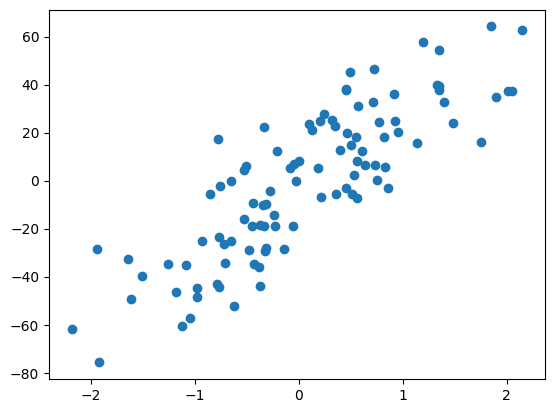

In [2]:
x,y=make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13)
plt.scatter(x,y)

In [3]:
lr=LinearRegression()
lr.fit(x,y)
print(lr.coef_)
print(lr.intercept_)

[27.82809103]
-2.29474455867698


In [4]:
rr=Ridge(alpha=10)
rr.fit(x,y)
print(rr.coef_)
print(rr.intercept_)

[24.9546267]
-2.1269130035235735


In [5]:
rr1=Ridge(alpha=100)
rr1.fit(x,y)
print(rr1.coef_)
print(rr1.intercept_)

[12.93442104]
-1.4248441496033308


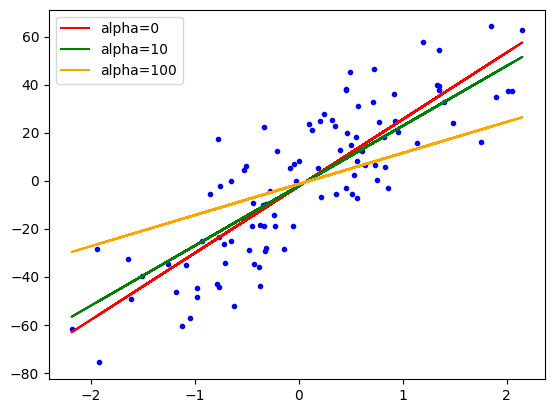

In [6]:
plt.plot(x,y,'b.')
plt.plot(x,lr.predict(x),color='red',label='alpha=0')
plt.plot(x,rr.predict(x),color='green',label='alpha=10')
plt.plot(x,rr1.predict(x),color='orange',label='alpha=100')
plt.legend()

In [7]:
class MeraRidge:
    def __init__(self,alpha=0.1):
        self.alpha=alpha
        self.m=None
        self.b=None

    def fit(self,x_train,y_train):
        num=0
        den=0
        for i in range(x_train.shape[0]):
            num=num+(y_train[i]-y_train.mean())*(x_train[i]-x_train.mean())
            den=den+(x_train[i]-x_train.mean())*(x_train[i]-x_train.mean())+self.alpha

            self.m=num/(den)
            self.b=y_train.mean()-(self.m*x_train.mean())
            print(self.m,self.b)
        
        def predict(x_test):
            pass

In [8]:
reg=MeraRidge(alpha=100)
reg.fit(x,y)

[0.25784548] [-0.68443844]
[0.1507408] [-0.67818274]
[0.13187594] [-0.67708089]
[0.14577269] [-0.67789256]
[0.12688372] [-0.67678931]
[0.10270941] [-0.67537735]
[0.09388874] [-0.67486216]
[0.08314689] [-0.67423475]
[0.0961106] [-0.67499193]
[0.10316997] [-0.67540425]
[0.16065601] [-0.67876186]
[0.15113026] [-0.67820549]
[0.1425052] [-0.67770172]
[0.13615189] [-0.67733064]
[0.13956305] [-0.67752987]
[0.14031002] [-0.6775735]
[0.13457765] [-0.67723869]
[0.1263148] [-0.67675608]
[0.16202113] [-0.67884159]
[0.16769544] [-0.67917301]
[0.17665555] [-0.67969635]
[0.16691601] [-0.67912749]
[0.17014031] [-0.67931581]
[0.21766928] [-0.68209186]
[0.20764193] [-0.68150618]
[0.22023129] [-0.6822415]
[0.21478] [-0.6819231]
[0.21103392] [-0.6817043]
[0.20896835] [-0.68158366]
[0.20106384] [-0.68112198]
[0.20458614] [-0.6813277]
[0.2037088] [-0.68127646]
[0.20216593] [-0.68118635]
[0.2092231] [-0.68159854]
[0.2419061] [-0.68350747]
[0.2508127] [-0.68402768]
[0.24382958] [-0.68361981]
[0.25075561] [-0.

Ridge Regression for N Dimensional Data

In [9]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [10]:
x,y=load_diabetes(return_X_y=True)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=4)

In [11]:
reg=Ridge(alpha=0.1,solver='cholesky')
reg.fit(x_train,y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'cholesky'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",No

In [12]:
y_pred=reg.predict(x_test)
r2_score(y_test,y_pred)

0.4693128853309805

In [13]:
print(reg.coef_)
print(reg.intercept_)

[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]
150.89053425602808


In [16]:
class MeraRidge:
    def __init__(self,alpha=0.1):
        self.alpha=alpha
        self.m=None
        self.b=None

    def fit(self,x_train,y_train):
        x_train=np.insert(x_train,0,1,axis=1)
        I=np.identity(x_train.shape[1])
        result=np.linalg.inv(np.dot(x_train.T,x_train)+self.alpha*I).dot(x_train.T).dot(y_train)
        self.intercept_=result[0]
        self.coef_=result[1:]
    def predict(self,x_test):
        return np.dot(x_test,self.coef_)+self.intercept_

In [19]:
reg=MeraRidge()
reg.fit(x_train,y_train)
y_pred=reg.predict(x_test)
print('r2 score: ',r2_score(y_test,y_pred))
print('reg coef: ',reg.coef_)
print('reg intercept:',reg.intercept_)


r2 score:  0.46921361559931907
reg coef:  [  44.04252774 -241.72019592  452.99153345  332.06044266  -76.32617866
  -68.54884462 -165.01664054  149.93980143  431.59483654   58.54419942]
reg intercept: 150.84762720023167
